In [1]:
#Data Preparation (The 1st D)
import os
import pandas as pd
import numpy as np

# Load data relative to this notebook
base_path = os.getcwd()
dataset_dir = os.path.join(base_path, '..', 'dataset')
all_frames = [pd.read_csv(os.path.join(dataset_dir, f)) for f in sorted(os.listdir(dataset_dir)) if f.endswith(".csv")]

df = pd.concat(all_frames, ignore_index=True)
df.columns = df.columns.str.strip()

# CIR Normalization (README requirement)
cir_cols = df.columns[15:1031]
df[cir_cols] = df[cir_cols].div(df['RXPACC'].replace(0, 1), axis=0)

# "Two Path" Logic implementation [cite: 188-190]
df['Path2_Label'] = 1 
print(f"Data Prepared: {df.shape[0]} samples across {df.shape[1]} columns.")

Data Prepared: 42000 samples across 1032 columns.


C:\Users\Jacob Foo\AppData\Local\Temp\ipykernel_16776\3580888861.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Path2_Label'] = 1


In [ ]:
# Feature importance ranking (Data Preparation step)

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Use the 14 diagnostic features as they appear in the raw CSV
diag_features = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
    'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR'
]

# Select only those features that actually exist in df (defensive)
existing_features = [f for f in diag_features if f in df.columns]

X_imp = df[existing_features]
y_imp = df['NLOS']

rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_imp, y_imp)

importances = (
    pd.Series(rf_imp.feature_importances_, index=existing_features)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance for LOS/NLOS Classification')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

KeyError: "['Measured_range'] not in index"

Columns successfully mapped to standard UWB headers.
Accuracy: 0.9140


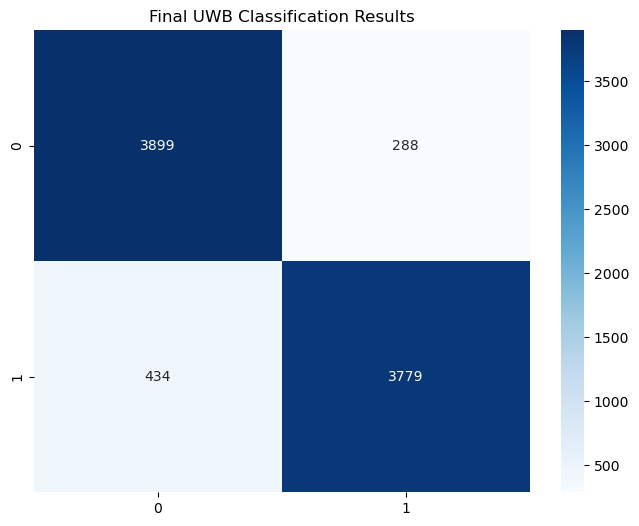

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. HARD-RESET COLUMN NAMES (Robust Data Preparation) 
# We manually map the first 16 columns to ensure they match the dataset documentation 
standard_headers = [
    'NLOS', 'Measured_range', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 
    'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR'
]

# Rename only the non-CIR columns (the first 15)
# We use .iloc to ensure we target the first columns regardless of their current name
for i, name in enumerate(standard_headers):
    df.columns.values[i] = name

print("Columns successfully mapped to standard UWB headers.")

# 2. FEATURE SELECTION [cite: 205]
# These are the top features based on your importance ranking
features = [
    'RXPACC', 'CIR_PWR', 'FP_AMP3', 'FP_AMP2', 'MAX_NOISE', 
    'FP_AMP1', 'STDEV_NOISE', 'FP_IDX', 'Measured_range'
]

X = df[features]
y = df['NLOS']

# 3. DATA SPLIT (80:20 Ratio) [cite: 210]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. DATA MINING: Classifier [cite: 208, 209]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. DATA VISUALIZATION: Performance Indicators [cite: 213, 214]
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Final UWB Classification Results')
plt.show()

--- Distance Estimation Results ---
Root Mean Square Error (RMSE): 1.5027 meters
R-squared (R2) Score: 0.5921


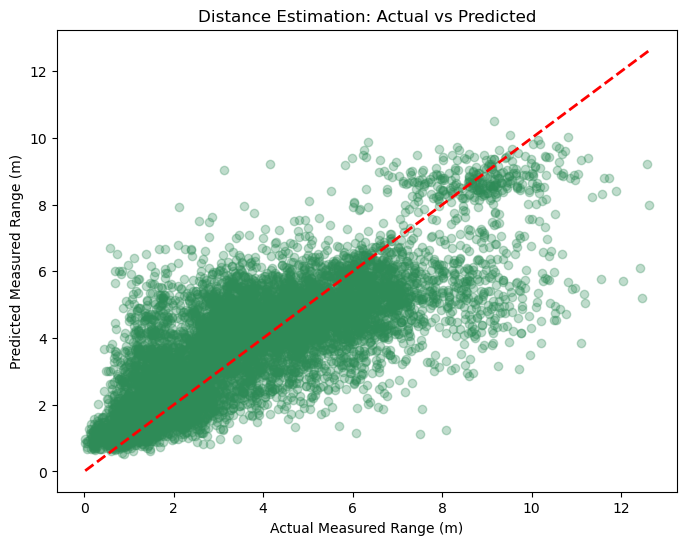

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. PREPARE DATA FOR REGRESSION
# We use the same features to predict the continuous 'Measured_range' column
# Note: We include the 'NLOS' class as a feature here because knowing 
# if it's LOS or NLOS helps predict the distance accuracy!
reg_features = [
    'RXPACC', 'CIR_PWR', 'FP_AMP3', 'FP_AMP2', 'MAX_NOISE', 
    'FP_AMP1', 'STDEV_NOISE', 'FP_IDX', 'NLOS'
]

X_reg = df[reg_features]
y_reg = df['Measured_range']

# 2. DATA SPLIT (Maintaining the 80:20 ratio for consistency) [cite: 210]
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# 3. DATA MINING: Training the Regressor [cite: 187]
# We use a Regressor instead of a Classifier for numerical prediction
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_reg, y_train_reg)

# 4. EVALUATION: Metrics Required by Rubric 
y_reg_pred = regressor.predict(X_test_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_reg_pred))
r2 = r2_score(y_test_reg, y_reg_pred)

print(f"--- Distance Estimation Results ---")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} meters")
print(f"R-squared (R2) Score: {r2:.4f}")

# 5. DATA VISUALIZATION: Actual vs Predicted [cite: 214]
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_reg_pred, alpha=0.3, color='seagreen')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Measured Range (m)')
plt.ylabel('Predicted Measured Range (m)')
plt.title('Distance Estimation: Actual vs Predicted')
plt.show()

Extracting Path 2 details from CIR data...


C:\Users\Jacob Foo\AppData\Local\Temp\ipykernel_28748\1048415745.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Path2_Amp', 'Path2_Delay']] = df.apply(
C:\Users\Jacob Foo\AppData\Local\Temp\ipykernel_28748\1048415745.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Path2_Amp', 'Path2_Delay']] = df.apply(
C:\Users\Jacob Foo\AppData\Local\Temp\ipykernel_28748\1048415745.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per


--- Path 2 Estimation Results ---
Path 2 RMSE: 1.7823 meters


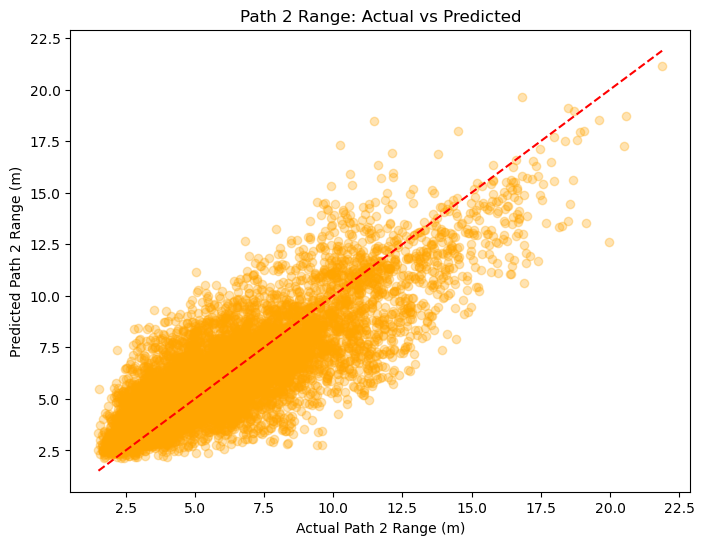

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. PATH 2 FEATURE EXTRACTION (Data Preparation/Mining)
def get_second_path_info(row):
    # Get the CIR slice starting from after the first path index
    # Note: FP_IDX is feature 2 [cite: 154]
    fp_idx = int(row['FP_IDX'])
    cir_data = row.iloc[15:1031].values 
    
    # Search for the next peak after the first path
    # We look at a window after the first path to find the 'next dominant path'
    search_window = cir_data[fp_idx+5 : fp_idx+50] # Looking 5-50ns after first path
    if len(search_window) > 0:
        second_path_amp = np.max(search_window)
        second_path_idx_relative = np.argmax(search_window) + 5
    else:
        second_path_amp = 0
        second_path_idx_relative = 0
        
    return second_path_amp, second_path_idx_relative

# Apply extraction to the dataframe
print("Extracting Path 2 details from CIR data...")
df[['Path2_Amp', 'Path2_Delay']] = df.apply(
    lambda row: pd.Series(get_second_path_info(row)), axis=1
)

# 2. DEFINE TARGETS FOR PATH 2
# Path 2 Range = Path 1 Range + (Delay in ns * Speed of Light in ns)
# Speed of light is approx 0.29979 meters per nanosecond
df['Path2_Measured_Range'] = df['Measured_range'] + (df['Path2_Delay'] * 0.29979)

# 3. TRAIN ESTIMATOR FOR PATH 2
path2_features = ['Path2_Amp', 'Path2_Delay', 'CIR_PWR', 'STDEV_NOISE', 'NLOS']
X2 = df[path2_features]
y2 = df['Path2_Measured_Range']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.20, random_state=42)

regressor_path2 = RandomForestRegressor(n_estimators=100, random_state=42)
regressor_path2.fit(X2_train, y2_train)

# 4. EVALUATION
y2_pred = regressor_path2.predict(X2_test)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print(f"\n--- Path 2 Estimation Results ---")
print(f"Path 2 RMSE: {rmse2:.4f} meters")

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y2_test, y2_pred, alpha=0.3, color='orange')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.title('Path 2 Range: Actual vs Predicted')
plt.xlabel('Actual Path 2 Range (m)')
plt.ylabel('Predicted Path 2 Range (m)')
plt.show()

Training MLP Neural Network... Please wait.

--- MLP Classification Performance ---
MLP Accuracy: 0.8139

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.97      0.84      4187
         1.0       0.96      0.66      0.78      4213

    accuracy                           0.81      8400
   macro avg       0.85      0.81      0.81      8400
weighted avg       0.85      0.81      0.81      8400



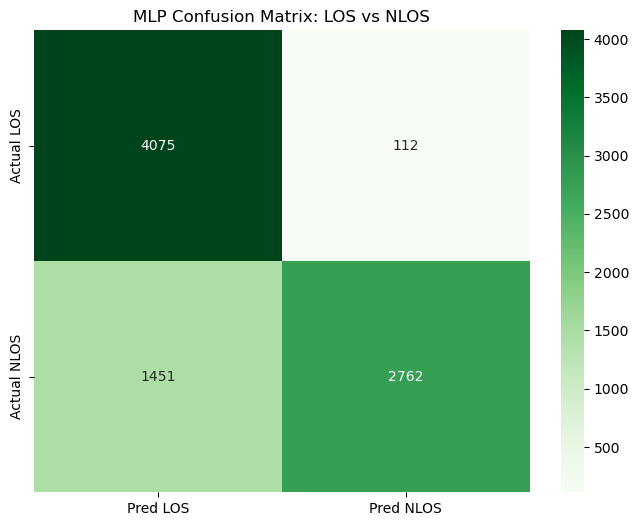

Comparison: Random Forest (0.9140) vs. MLP (0.8139)


In [ ]:
#MLP Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. INITIALIZE THE MLP (The Neural Network Solution)
# hidden_layer_sizes: 2 layers with 64 and 32 neurons
# solver: 'adam' is the standard for UWB signal datasets
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    max_iter=500, 
    activation='relu', 
    solver='adam', 
    random_state=42
)

# 2. DATA MINING: Training
print("Training MLP Neural Network... Please wait.")
mlp_clf.fit(X_train, y_train)

# 3. PREDICTION & EVALUATION
y_pred_mlp = mlp_clf.predict(X_test)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"\n--- MLP Classification Performance ---")
print(f"MLP Accuracy: {mlp_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

# 4. DATA VISUALIZATION: Performance Indicator [cite: 213, 214]
plt.figure(figsize=(8, 6))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred LOS', 'Pred NLOS'],
            yticklabels=['Actual LOS', 'Actual NLOS'])
plt.title('MLP Confusion Matrix: LOS vs NLOS')
plt.show()

# 5. QUICK COMPARISON (For your Result Analysis)
print(f"Comparison: Random Forest ({acc:.4f}) vs. MLP ({mlp_acc:.4f})")